# Assignment 4

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

In [2]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('./album_sales.csv')
df.head()


,sales,adverts,airplay,attract
0,330,10.256,43,10
1,120,985.685,28,7
2,360,1445.563,35,7
3,270,1188.193,33,7
4,220,574.513,44,5


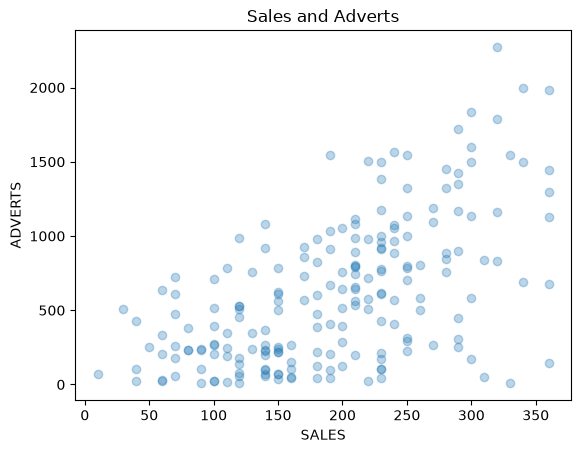

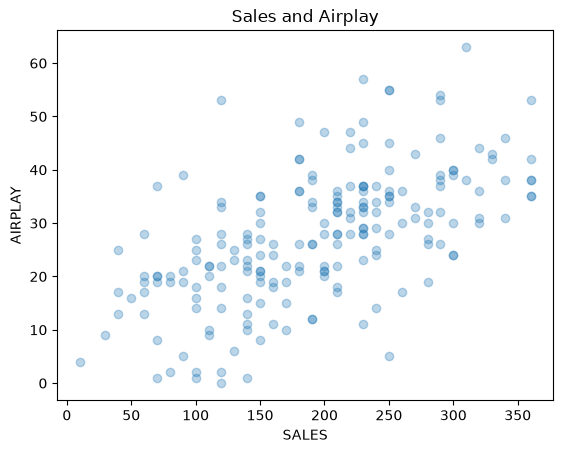

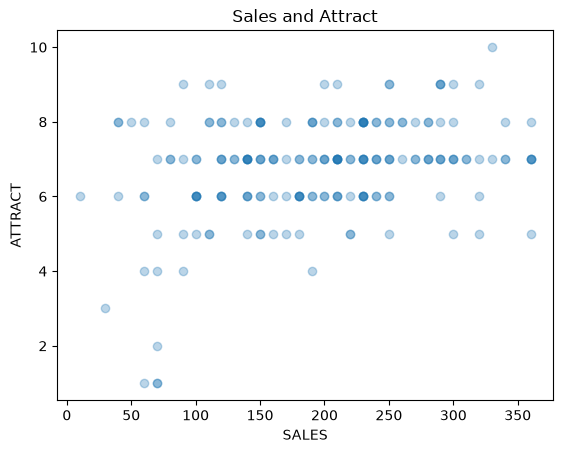

SALES & ADVERTS          BLUE
SALES & AIRPLAY          ORANGE
SALES & ATTRACT          GREEN


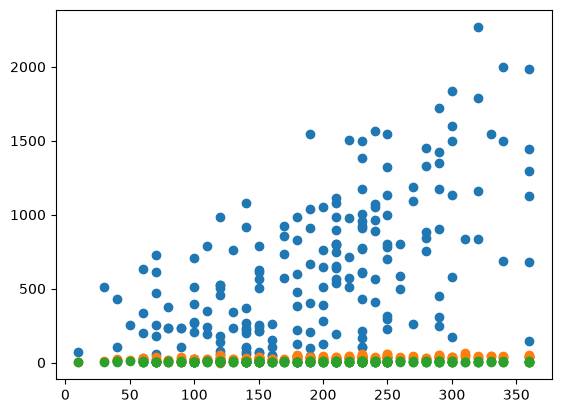

In [10]:

#-------------------------------------------------------

plt.scatter(df['sales'], df['adverts'], alpha=0.3)
plt.xlabel('SALES')
plt.ylabel('ADVERTS')
plt.title('Sales and Adverts')
plt.show()

#-------------------------------------------------------

plt.scatter(df['sales'], df['airplay'], alpha=0.3)
plt.xlabel('SALES')
plt.ylabel('AIRPLAY')
plt.title('Sales and Airplay')
plt.show()

#-------------------------------------------------------

plt.scatter(df['sales'], df['attract'], alpha=0.3)
plt.xlabel('SALES')
plt.ylabel('ATTRACT')
plt.title('Sales and Attract')
plt.show()

# Code here
print("SALES & ADVERTS          BLUE")
plt.scatter(df["sales"], df["adverts"])

print("SALES & AIRPLAY          ORANGE")
plt.scatter(df["sales"], df["airplay"])

print("SALES & ATTRACT          GREEN")
plt.scatter(df["sales"], df["attract"])
plt.show()



In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

sales and advertisement have a positve relationship.
sales and airplay have a positve relationship.
sales and attractiveness don't really seem to have much of a correlation.


### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

In [12]:
# Code here
x = df['adverts']
y = df['sales']
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
print(model.summary())
print("F-statistic:", model.fvalue)
print("P-value:", model.f_pvalue)


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        14:52:53   Log-Likelihood:                -1120.7
No. Observations:                 200   AIC:                             2245.
Df Residuals:                     198   BIC:                             2252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        134.1399      7.537     17.799      0.0

In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

Thr F-statistic is 99.59 and the P-value is 2.94 x 10^-19. Since the P-value is less that 0.05 the regression model is statistacally significant.

### 3. Model Coefficients (10 points)

- Make note of the **intercept** value and **coefficient** (adverts) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [ ]:
# Code here   advertising is messured by the thousands so in this 135 = 135,000
advertising = 135
predicted_sales = model.params["const"] + model.params["adverts"] * advertising #regression equation
print("Predicted Sales(In thousands): ", predicted_sales)



Intercept: 134.13993781207427
Advertising coefficient: 0.09612448597387711
Predicted Sales:  147.11674341854768


### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [15]:
# Code here
X = df[['adverts', 'airplay', 'attract']]
Y = df['sales']
X = sm.add_constant(X)

multiple_model = sm.OLS(Y,X).fit()
print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        15:11:34   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.

Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

In [17]:
print("Model 1 R-squared:", model.rsquared)
print("Model 1 P-value:", model.f_pvalue)
print("-------------------------------------------------------")
print("Model 2 R-squared:", multiple_model.rsquared)
print("Model 2 P-value:", multiple_model.f_pvalue)

Model 1 R-squared: 0.3346480676230732
Model 1 P-value: 2.941979852165935e-19
-------------------------------------------------------
Model 2 R-squared: 0.6646676869745163
Model 2 P-value: 2.8755350564876177e-46


Model 2 is better because it has a higher r-squared (0.665 vs. 0.335) and both models have P-values below 0.05.

### Submission
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name